# single agent plots

## outline
 - trial schema plot
 - attention prob and lick prob in a example trial
 - series of attention time plot, same as the AF_IRC notebook, to visualize the perodic attention

## import

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
sys.path.append(f'{os.getcwd()}/irc_gym')

In [3]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2
from stable_baselines3 import PPO
from irc_gym.irc.model import FuncBeliefModel
from multiprocessing import Pool
import multiprocessing as mp
import multiprocessing
from ult import *
from auditoryforage.utils import plot_AF_episode

## Analysis within trial

## settings

In [4]:
# template for training
print('''
    date 5.5
    goal:
      nice periodic,
    new: 
      log scale food reward list
      56. 
    comments:
      try 56 first.
''')
# training hyper params
epoch_size = 11111
eval_size = 999
n_epoch = 66
n_seed=1

# reward list
vmin, vmax=np.log(10),np.log(10000)
food_reward_list = np.linspace(vmin, vmax, 11)
food_reward_list=np.exp(food_reward_list)
print('food reard list: ', [f'{a:.0f}' for a in food_reward_list])

# other env params
env_param = [0, 1500, 0.087213, .25, -30, 0, 0]
#
modelname='newbase'


    date 5.5
    goal:
      nice periodic,
    new: 
      log scale food reward list
      56. 
    comments:
      try 56 first.

food reard list:  ['10', '20', '40', '79', '158', '316', '631', '1259', '2512', '5012', '10000']


In [5]:
seed=0
agent=PPO.load(f'ycstore/seed_{seed}_{modelname}', device='cpu')

task = AFR2(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})
num_epochs = 1
task.food_reward_list = food_reward_list

taskbelief = FuncBeliefModel(env=task, rng=1)

no_episodes = 9999

### Visualize episode

In [6]:
task.lick_cost, task.attention_cost_coeff, task.attention_cost_temp, task.penalty_cost, task.iti_cost,task.time_in_game_reward

(0, 0.087213, 0.25, -30, 0, 0)

reward:  630.9573444801938


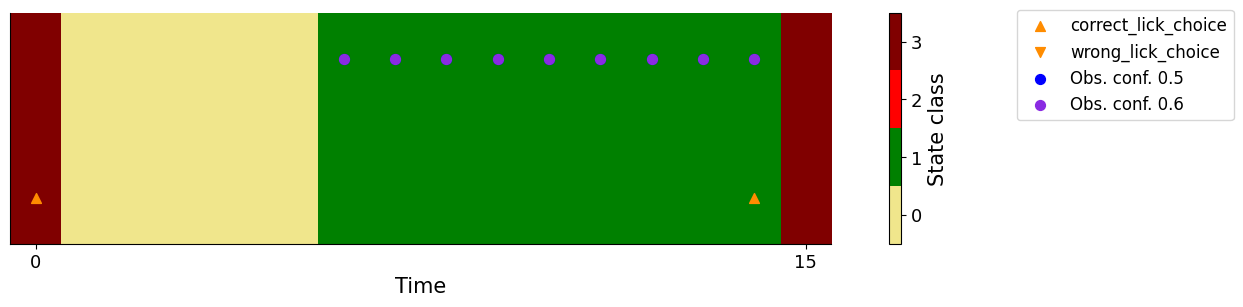

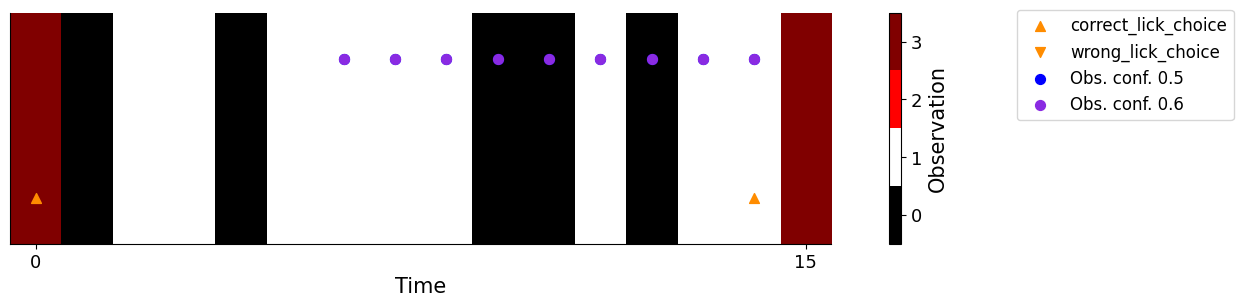

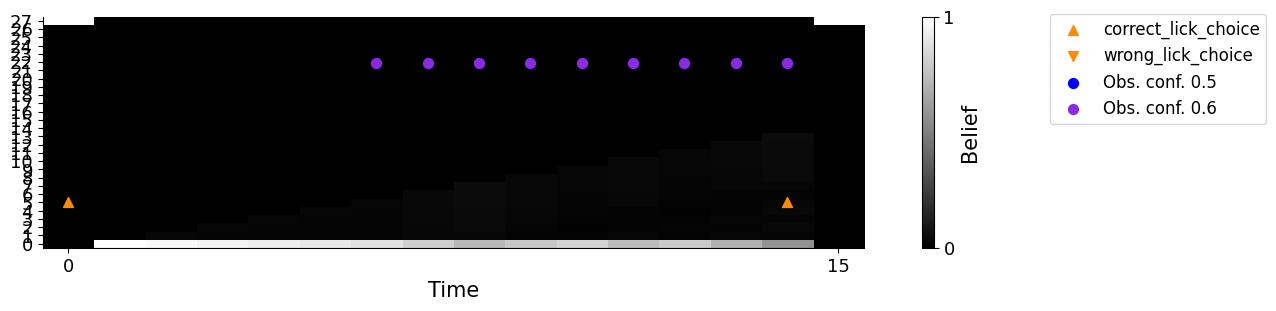

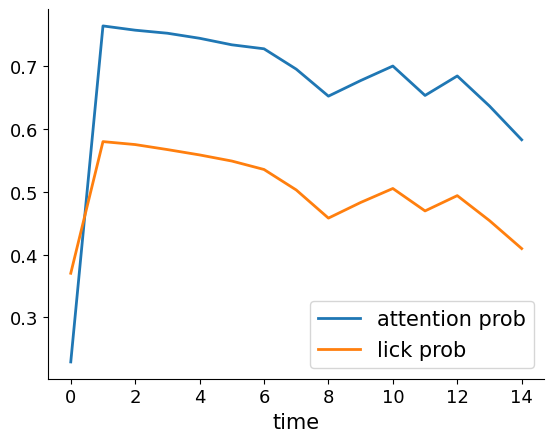

In [7]:
episode = run_one_episode(task, taskbelief, agent,
                          num_steps=1000)
print('reward: ',food_reward_list[episode['trial_food_reward_idx']])
fig = plot_AF_episode(episode, task, agent, nodes_from_zero = 40, time_steps_before_lick = 20)

activations_list = []
for belief in episode['beliefs'][:-1]: #Last belief is not used for action
    activations_list.append(find_activation(agent, belief).numpy())


lick_feature = [activations_list[ind][0]  for ind in range(len(activations_list))]
attention_feature = [activations_list[ind][1] for ind in range(len(activations_list))]
plt.figure()
plt.plot([(1/(1+np.exp(-2 * elt))) for elt in attention_feature], label = 'attention prob')
plt.plot([(1/(1+np.exp(-2 * elt))) for elt in lick_feature], label = 'lick prob')
plt.xlabel('time')
plt.legend()
plt.show()

## Analysis over trials

### Time analysis - plots

In [8]:
# run mp job
def eval_wrapper(a):
    episode = run_one_episode(task=task, taskbelief=taskbelief, agent=agent,
                              num_steps=100000)
    return episode

with multiprocessing.Pool(processes=27) as pool:
    all_episode_data = pool.map(eval_wrapper, range(no_episodes))

all_reward_res={} # k: v = foodreward: this food reward res
for r in range(len(food_reward_list)):
    attention_prob_list,lick_prob_list,lick_time_list,att_time_list, trial_len=[],[],[],[],[]
    all_reward_res[r]=attention_prob_list,lick_prob_list,lick_time_list,att_time_list, trial_len


for episode in all_episode_data:
    attention_prob_list,lick_prob_list,lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
    att_time_list.append(
        np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
    attention_prob, lick_prob = get_att_lick_probs(episode, agent)
    attention_prob_list.append(attention_prob)
    lick_prob_list.append(lick_prob)
    if episode['actions'][-1][0] == 1:
        lick_time_list.append(len(episode['states']))
    trial_len.append(len(episode['actions']))

max() iterable argument is empty
max() iterable argument is empty


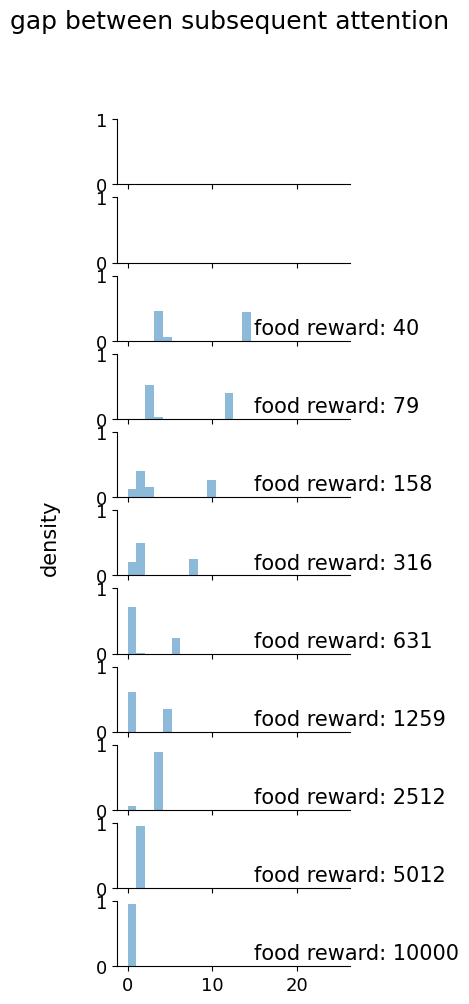

In [9]:
# plot
fig, axs=plt.subplots(len(food_reward_list),1, figsize=(3,len(food_reward_list)), sharex=True)
for food_reward_idx in all_reward_res.keys():
    try:
        attention_prob_list,lick_prob_list,lick_time_list,att_time_list,trial_len=all_reward_res[food_reward_idx]
        ax=axs[food_reward_idx]
        
        data=att_time_list
        v = find_gap(pad_zero_attention(data))
        # v = (v - min(v)) / (max(v) - min(v))
        # v = 1-v
        # sns.kdeplot(v, fill=False, bw_adjust=0.99,ax=ax)
        ax.text(15,0.1,f'food reward: {food_reward_list[food_reward_idx]:.0f}')
        ax.hist(v, alpha=0.5, bins=np.linspace(0,25,25), density= True)
        ax.set_ylim(0,1)
    except Exception as e:
        print(e)
        continue
fig.text(-0.1, 0.5, 'density', va='center', ha='center', rotation='vertical')
title = 'gap between subsequent attention' 
plt.suptitle(title)
# plt.legend()
plt.show()

## orginal plots

food reward: 10.000000000000002
max() iterable argument is empty
bad food reward: 10.000000000000002
food reward: 19.952623149688797
max() iterable argument is empty
bad food reward: 19.952623149688797
food reward: 39.810717055349734


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

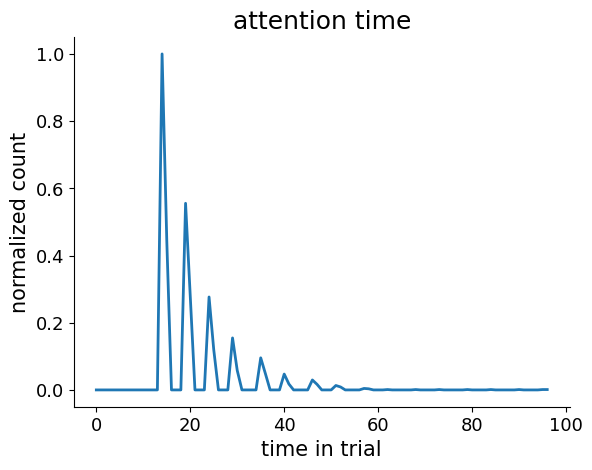

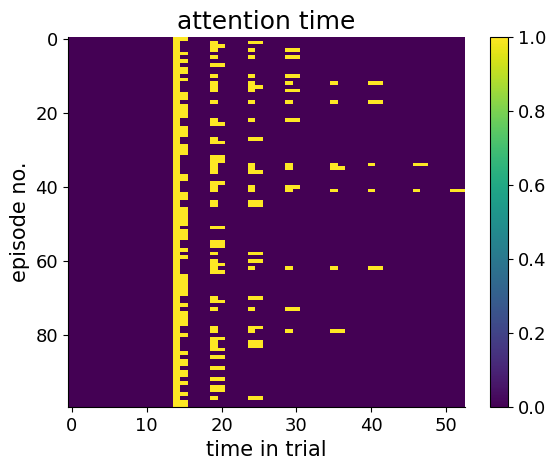

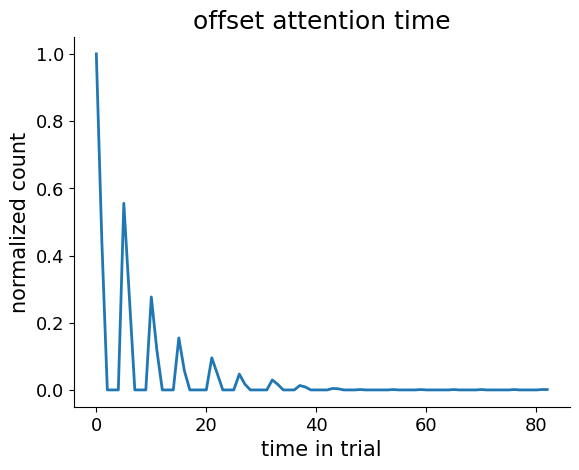

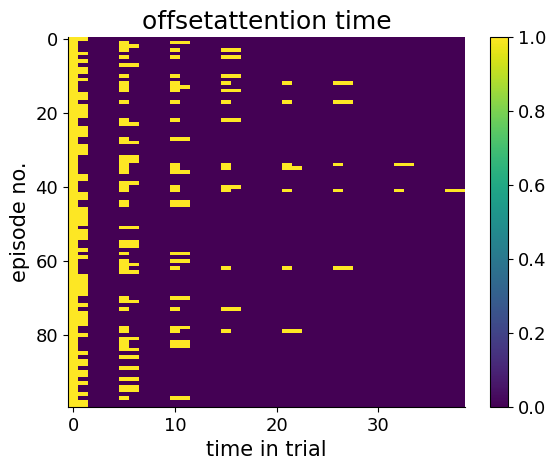

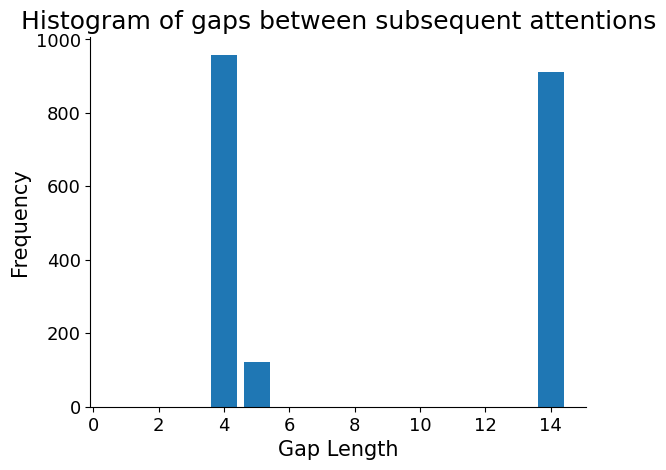

food reward: 79.4328234724282


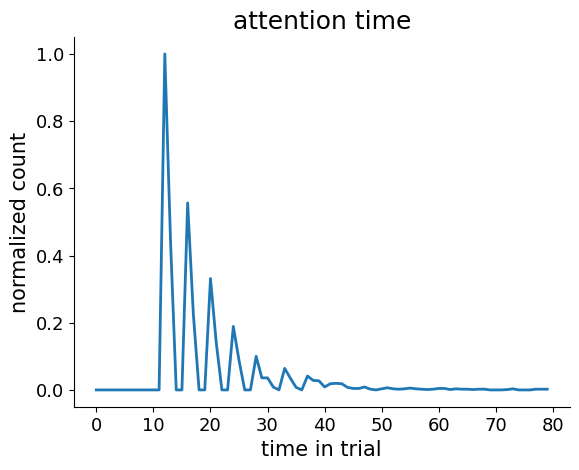

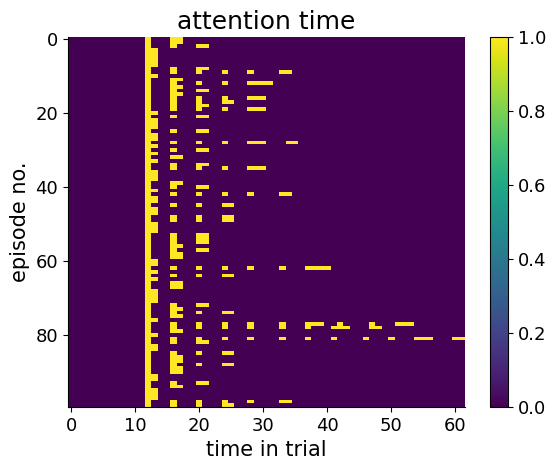

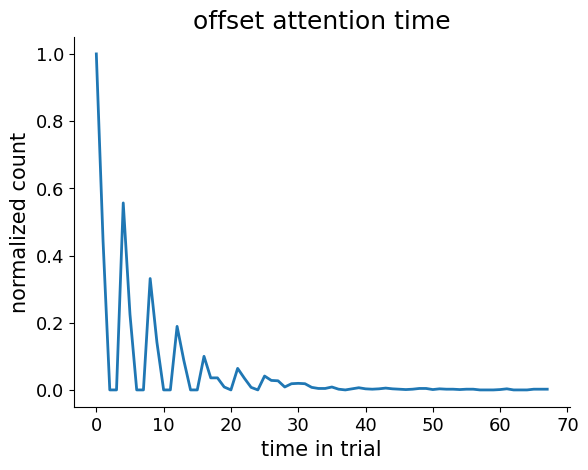

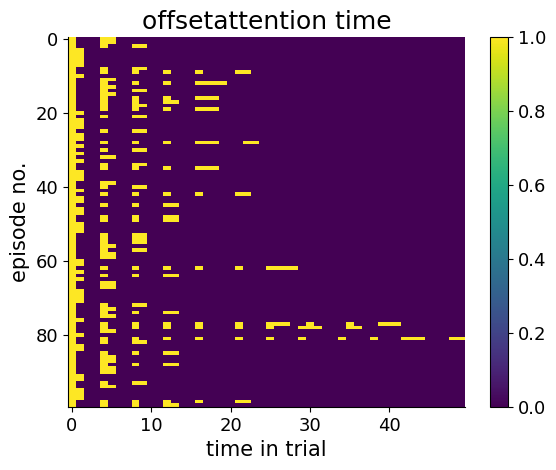

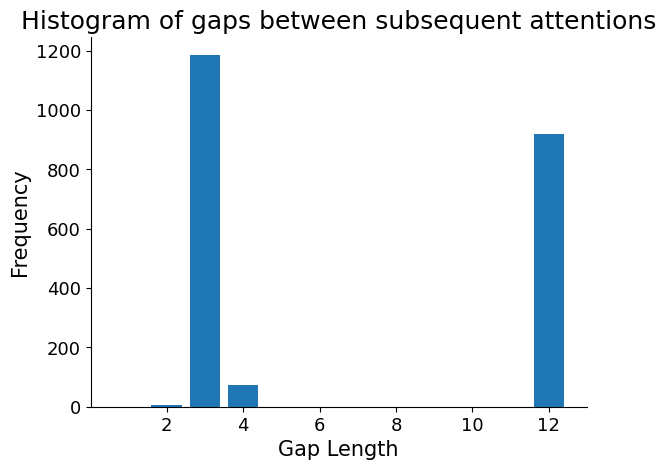

food reward: 158.4893192461114


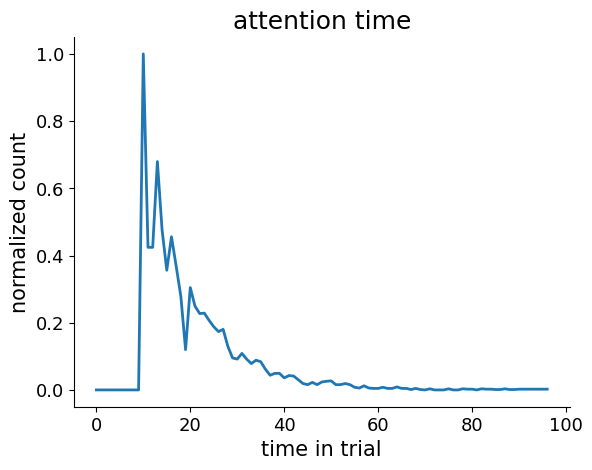

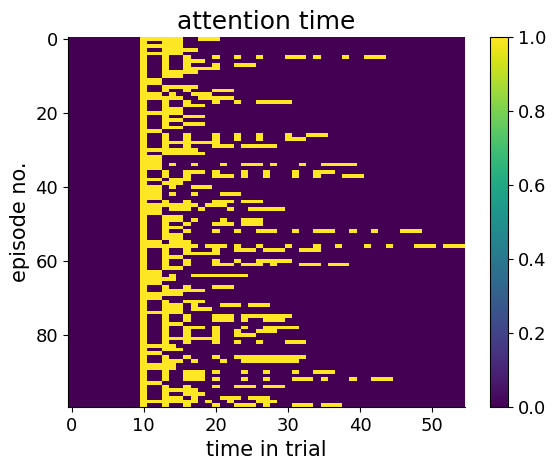

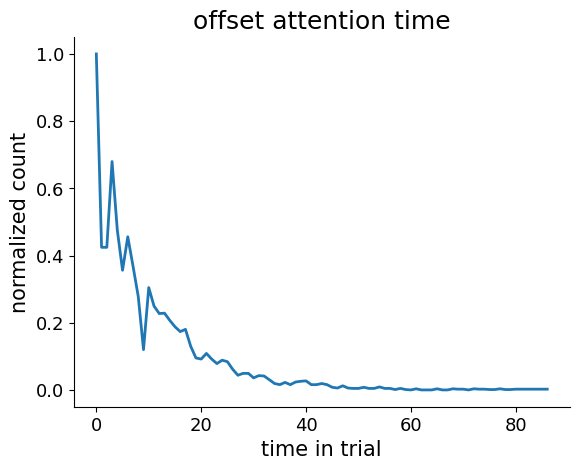

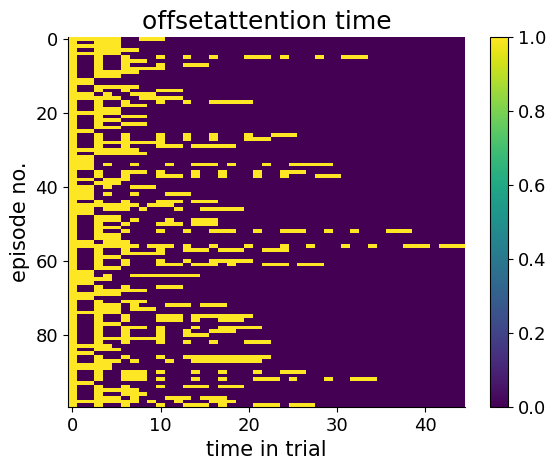

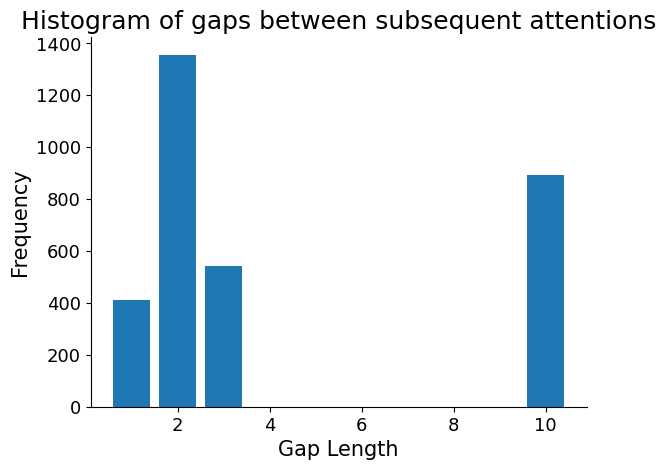

food reward: 316.22776601683796


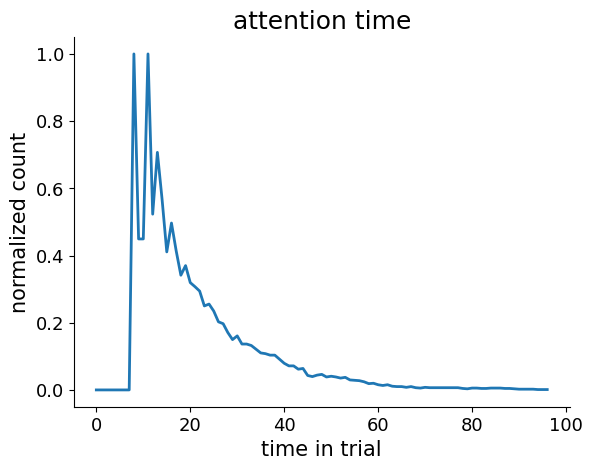

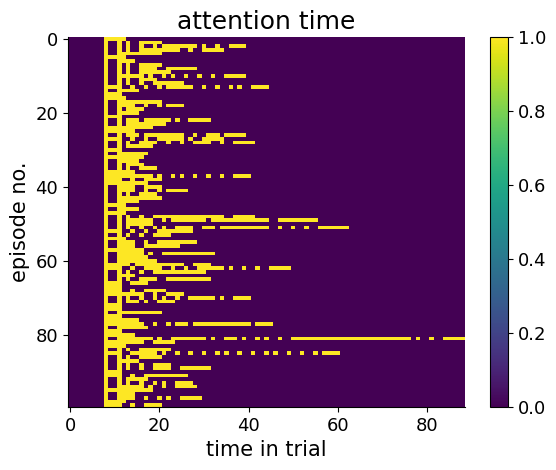

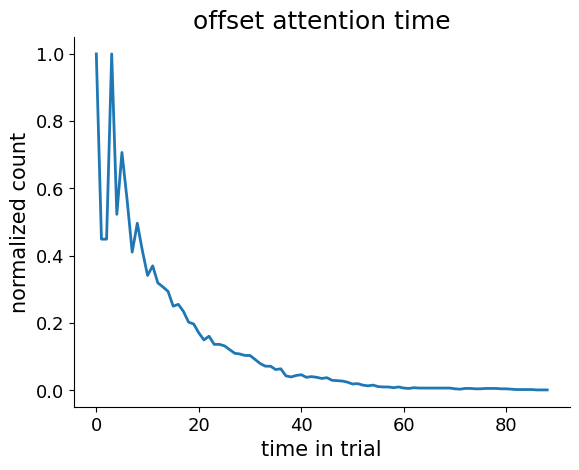

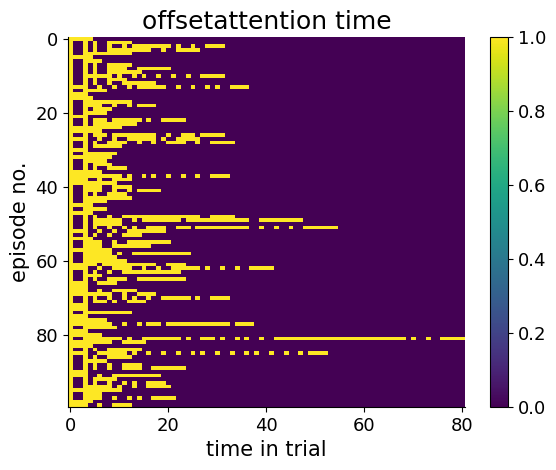

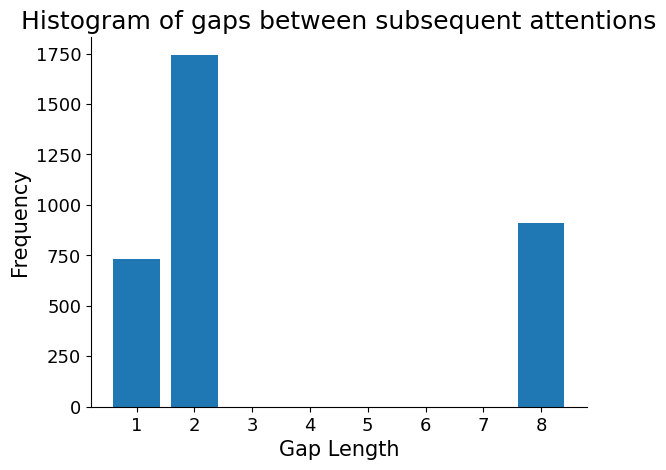

food reward: 630.9573444801938


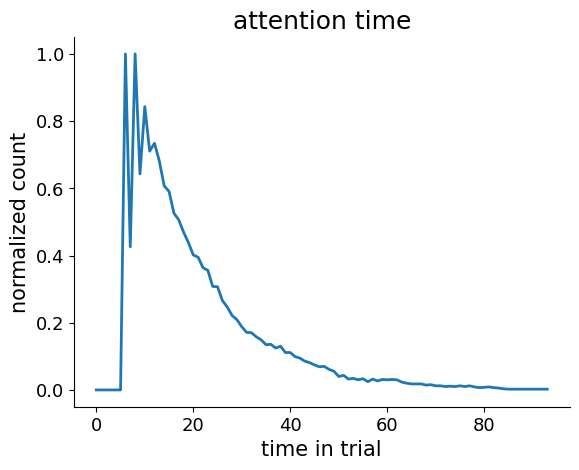

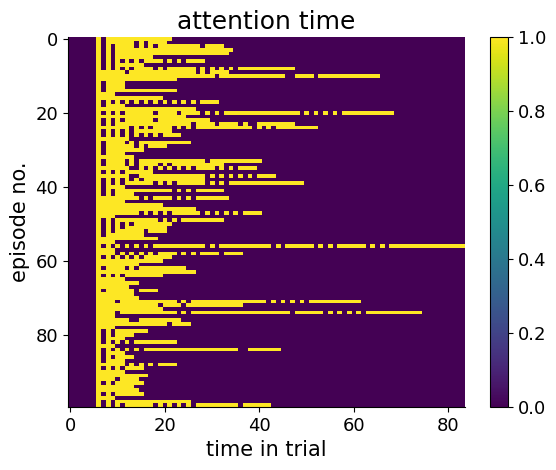

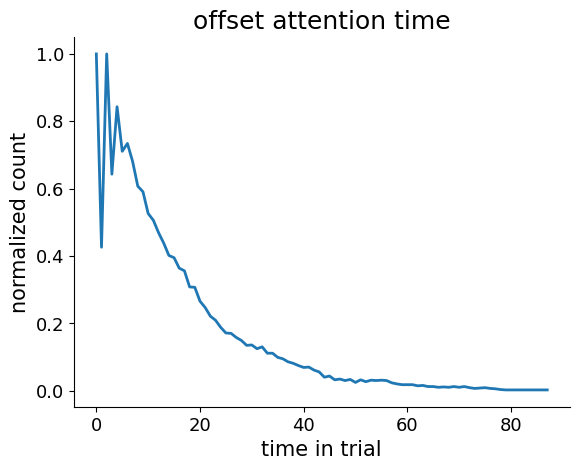

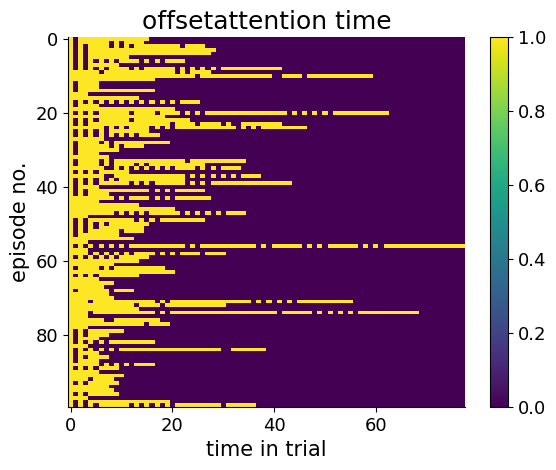

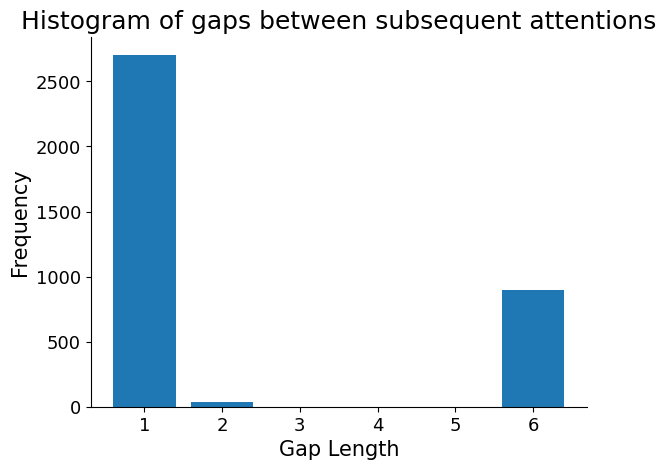

food reward: 1258.925411794168


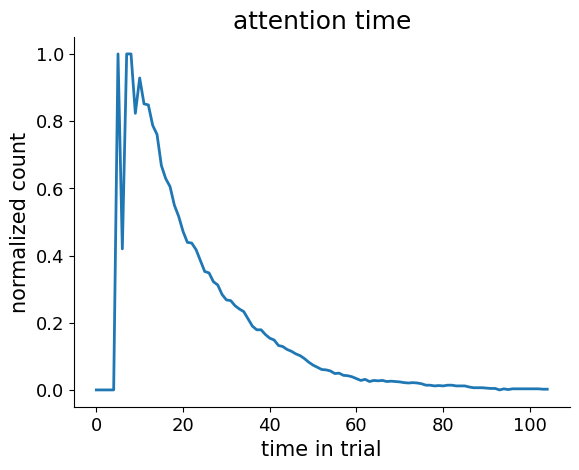

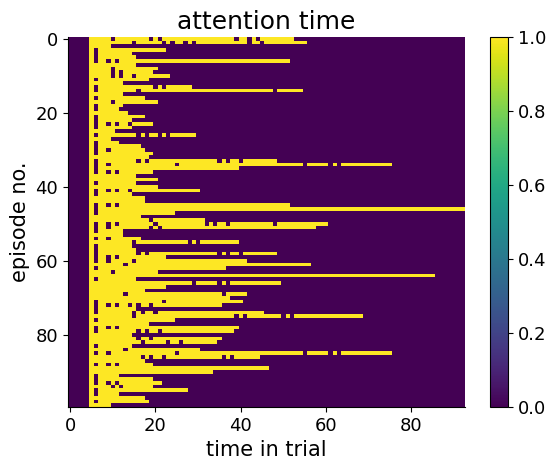

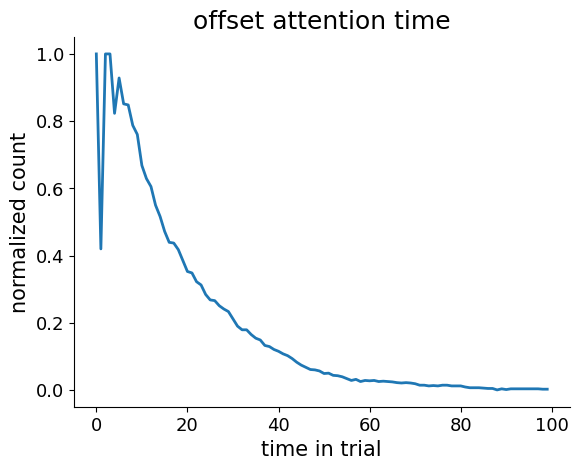

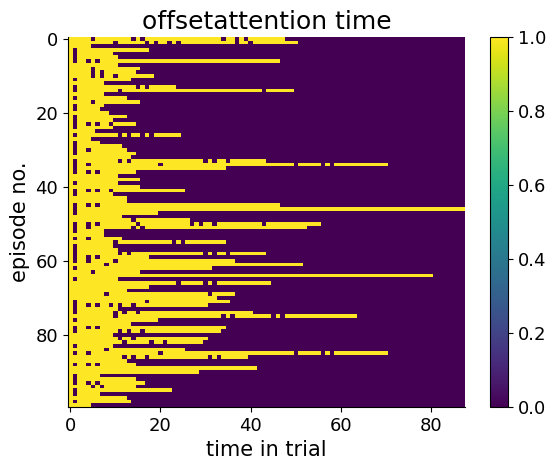

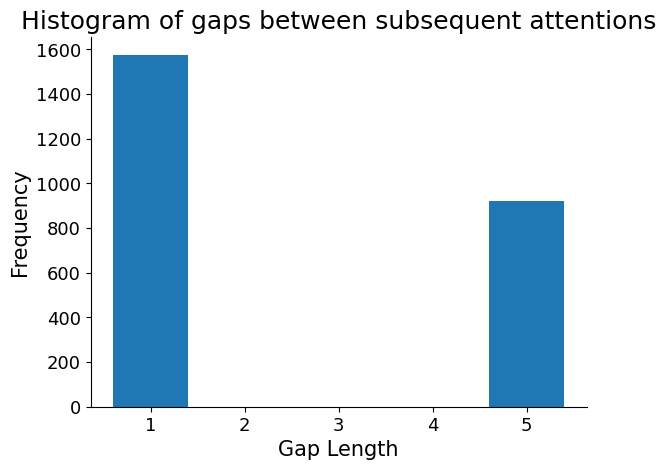

food reward: 2511.886431509581


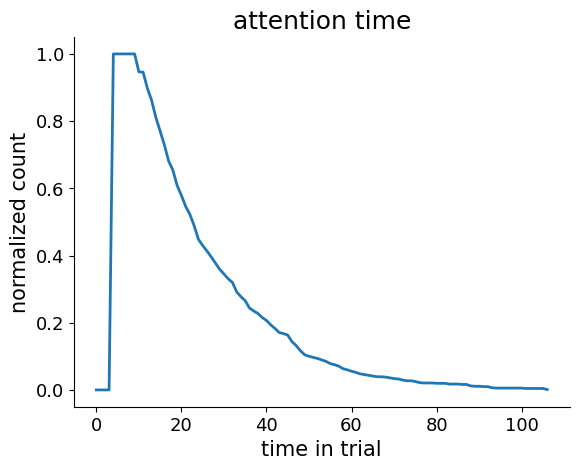

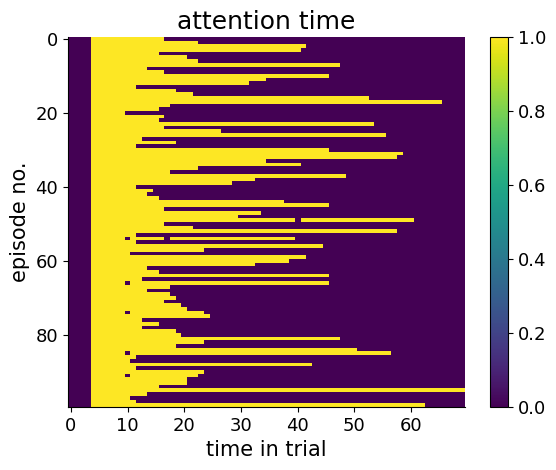

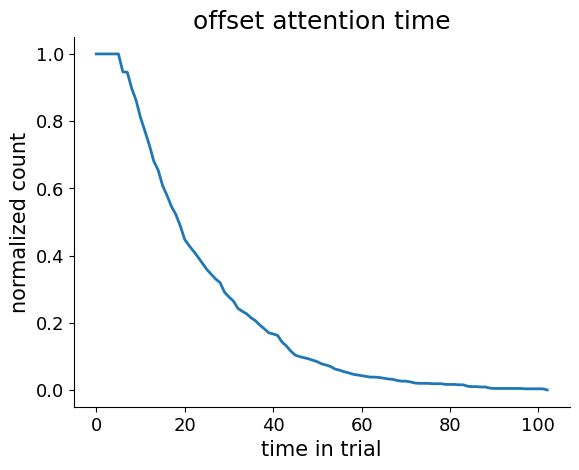

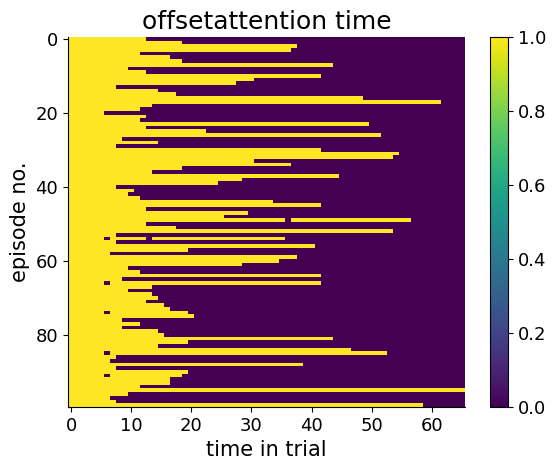

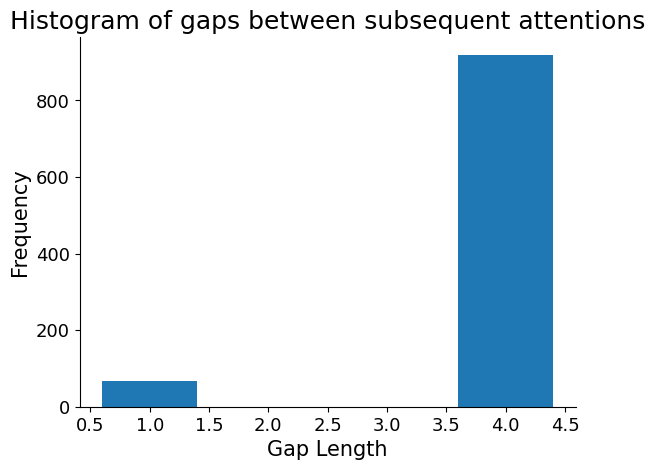

food reward: 5011.872336272724


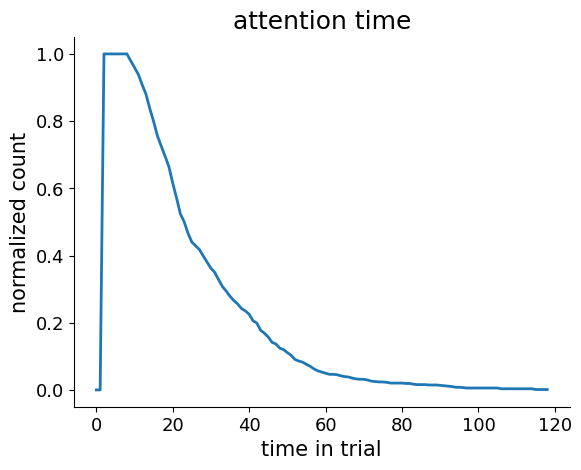

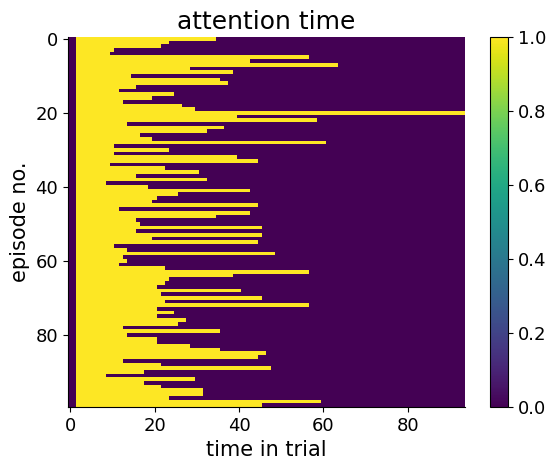

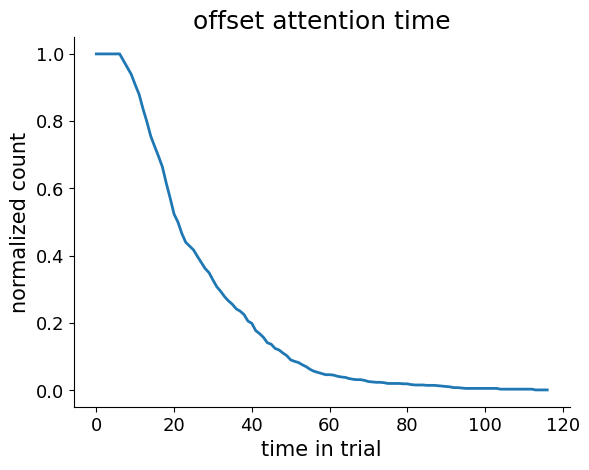

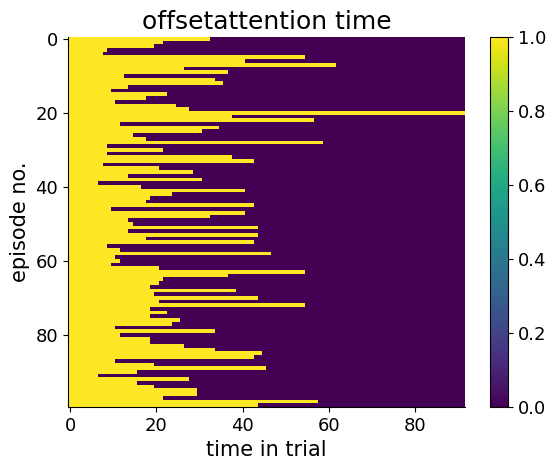

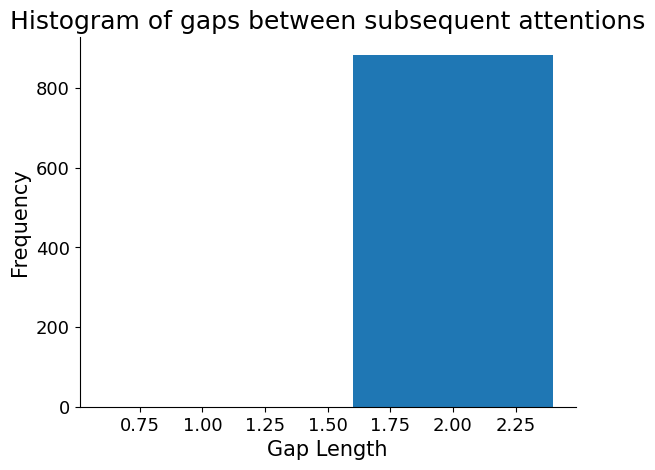

food reward: 10000.00000000001


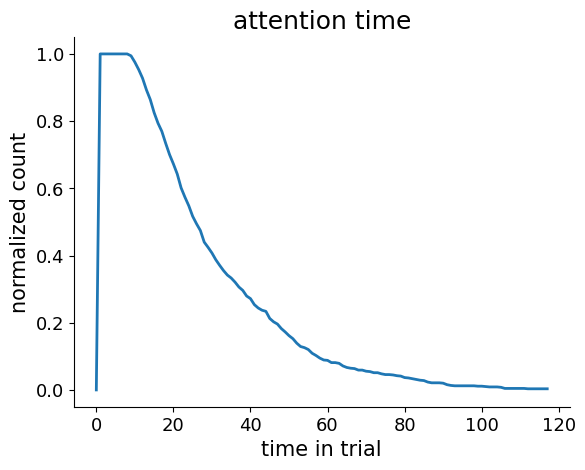

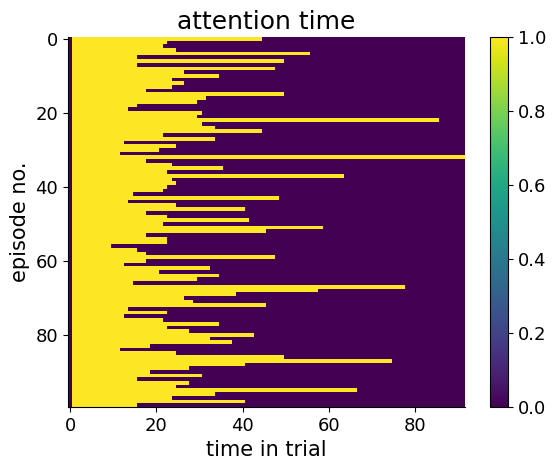

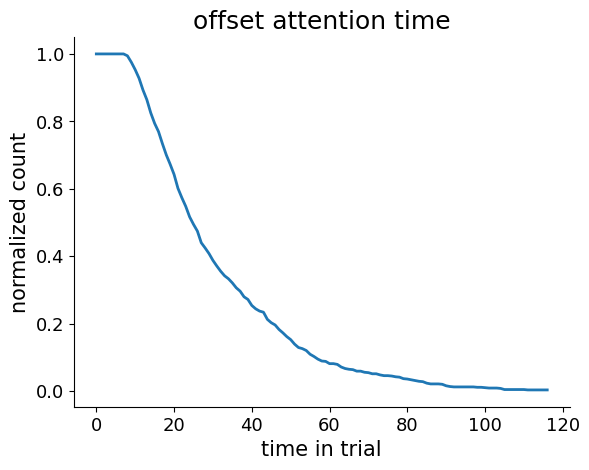

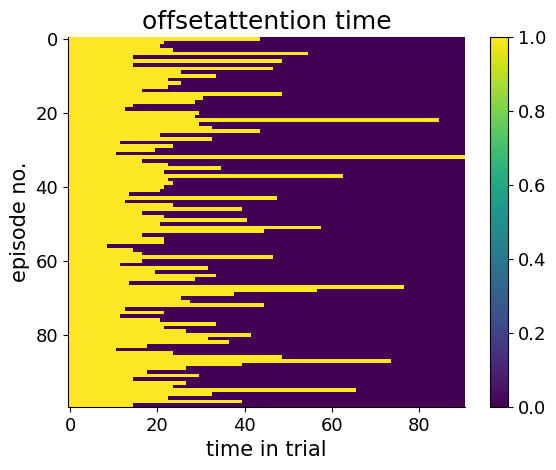

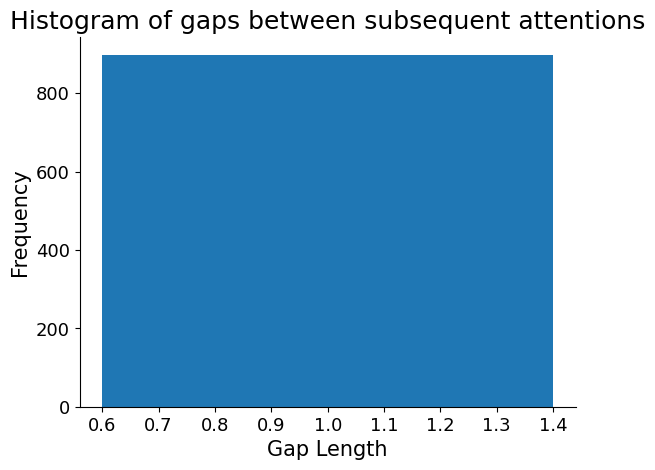

In [10]:
for food_reward_idx in all_reward_res.keys():
    attention_prob_list,lick_prob_list,lick_time_list,att_time_list,trial_len=all_reward_res[food_reward_idx]
    print(f'food reward: {food_reward_list[food_reward_idx]}')
    try:
        # plot_over_episodes(attention_prob_list, title = 'attention prob.', plot_no_episodes = 100)
        # plot_over_episodes(lick_prob_list, title = 'lick prob.', plot_no_episodes = 100)
        # plot_over_episodes(lick_time_list, title = 'lick time', plot_no_episodes = 100)
        plot_over_episodes(att_time_list, title = 'attention time', plot_no_episodes = 100)
    except Exception as e:
        print(e)
        print(f'bad food reward: {food_reward_list[food_reward_idx]}')
        continue

In [11]:
notify()